In [2]:
import os
from langgraph.graph import StateGraph, MessagesState, START, END
from typing import TypedDict, Annotated, List
from langchain_groq import ChatGroq
from langchain_classic import PromptTemplate

In [3]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [4]:
import pandas as pd

df = pd.read_csv("house_price.csv")

unit_multiplier = {"Cr": 100, "L": 1}
df["price_lakh"] = (
    (df["price"] * df["price_unit"].map(unit_multiplier)).round().astype("int64")
)

df = df.drop(columns=["Unnamed: 0", "price", "price_unit"])

print(df.head())

   bhk       type  area   region              status  price_lakh
0    3  Apartment  1076  Andheri  Under Construction         319
1    3  Apartment  1076  Andheri  Under Construction         319
2    3  Apartment  1076  Andheri  Under Construction         319
3    2  Apartment   718  Andheri  Under Construction         212
4    3  Apartment  1076  Andheri  Under Construction         319


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5042 entries, 0 to 5041
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   bhk         5042 non-null   int64
 1   type        5042 non-null   str  
 2   area        5042 non-null   int64
 3   region      5042 non-null   str  
 4   status      5042 non-null   str  
 5   price_lakh  5042 non-null   int64
dtypes: int64(3), str(3)
memory usage: 236.5 KB


In [6]:
df.head()

,bhk,type,area,region,status,price_lakh
0,3,Apartment,1076,Andheri,Under Construction,319
1,3,Apartment,1076,Andheri,Under Construction,319
2,3,Apartment,1076,Andheri,Under Construction,319
3,2,Apartment,718,Andheri,Under Construction,212
4,3,Apartment,1076,Andheri,Under Construction,319


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5042 entries, 0 to 5041
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   bhk         5042 non-null   int64
 1   type        5042 non-null   str  
 2   area        5042 non-null   int64
 3   region      5042 non-null   str  
 4   status      5042 non-null   str  
 5   price_lakh  5042 non-null   int64
dtypes: int64(3), str(3)
memory usage: 236.5 KB


In [8]:
from sqlalchemy import create_engine

engine = create_engine("sqlite:///house_prices.db")

In [9]:
df.to_sql("house_prices", engine, if_exists="replace", index=False)

5042

In [10]:
from sqlalchemy import text

with engine.connect() as conn:
    result = conn.execute(text("SELECT * FROM house_prices LIMIT 5"))
    for row in result:
        print(row)

(3, 'Apartment', 1076, 'Andheri', 'Under Construction', 319)
(3, 'Apartment', 1076, 'Andheri', 'Under Construction', 319)
(3, 'Apartment', 1076, 'Andheri', 'Under Construction', 319)
(2, 'Apartment', 718, 'Andheri', 'Under Construction', 212)
(3, 'Apartment', 1076, 'Andheri', 'Under Construction', 319)


In [11]:
from sqlalchemy import inspect

inspector = inspect(engine)

tables = inspector.get_table_names()

schema = {}

for table in tables:
    columns = inspector.get_columns(table)
    schema[table] = [col["name"] for col in columns]

print(schema)

{'house_prices': ['bhk', 'type', 'area', 'region', 'status', 'price_lakh']}


In [12]:
def run_query(sql):
    with engine.connect() as conn:
        result = conn.execute(text(sql))
        return result.fetchall()


print(
    run_query(
        """SELECT region, AVG(price_lakh) 
                FROM house_prices 
                GROUP BY region;"""
    )
)

[('Andheri', 281.25324675324674), ('Bandra', 613.859756097561), ('Dadar', 533.4423076923077), ('Ghatkopar', 177.1214351425943), ('Lower Parel', 813.9481707317074), ('Mumbai', 30.0)]


In [13]:
template = PromptTemplate.from_template(
    """
    You are an SQL expert.

    Schema:
    {schema}

    Convert question to SQL and dont add any extra contents also do with proper syntax,dont add any extra charcters:
    {question}
    """
)

In [14]:
chain = template | llm

In [15]:
op = chain.invoke({"schema": schema, "question": "Find out the avg price?"})

In [16]:
print(op)

content='SELECT AVG(price_lakh) FROM house_prices' additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 105, 'total_tokens': 115, 'completion_time': 0.023147076, 'completion_tokens_details': None, 'prompt_time': 0.038694064, 'prompt_tokens_details': None, 'queue_time': 0.36323999, 'total_time': 0.06184114}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_0761e44d7b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019d6c99-2d29-7942-8255-26967cfc043a-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 105, 'output_tokens': 10, 'total_tokens': 115}


In [17]:
def run_query(sql):
    with engine.connect() as conn:
        result = conn.execute(text(sql))
        return result.fetchall()


print(run_query(op.content))

[(336.2669575565252,)]


In [ ]:
class SQLState(TypedDict):
    query: str
    first_llm: str
    second_llm: str

In [25]:
def text_to_sql(state: SQLState):
    template = PromptTemplate.from_template(
        """
        You are an SQL expert.

        Schema:
        {schema}

        Convert question to SQL and dont add any extra contents also do with proper syntax,dont add any extra charcters:
        {question}
        """
    )

    chain = template | llm

    op = chain.invoke({"schema": schema, "question": state["query"]})

    return {"first_llm": op.content}

In [ ]:
def validator_sql_query(state: SQLState):
    template = PromptTemplate.from_template(
        """You are an SQL expert.You have a schema of a database and a SQL query generated by an LLM. Validate the SQL query for syntax and correctness based on the provided schema. If the query is valid give the output as same query . If the query is invalid generate the correct query and dont give any extra contents.
        
        Schema:
        {schema}
        
        Generated Query:
        {query}
        """
    )
    chain = template | llm

    res = chain.invoke({"schema": schema, "question": state["query"]})

    return {"first_llm": res.content}

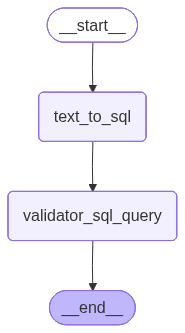

In [28]:
graph = StateGraph(SQLState)
graph.add_node("text_to_sql", text_to_sql)
graph.add_node("validator_sql_query", validator_sql_query)

graph.add_edge(START, "text_to_sql")
graph.add_edge("text_to_sql", "validator_sql_query")

graph.add_edge("validator_sql_query", END)

graph.compile()